# 03 - Resource Deliverability, Monte-Carlo MWth & Hybrid Design
**SPE Africa Geothermal Datathon 2026 - Challenges 1 & 2 - Team Vent Squad**

This is the deciding notebook: **can the resource meet the 10 MWth heating /
5 MWth cooling demand, and what does the surface scheme cost?** Every figure and
number is recomputed live from `src/` (no LightGBM needed).

**What this establishes**
1. The Darcy doublet model reconciles to ThermoGIS's *own* published flow/power.
2. A single BLT-01 doublet is ~5 MWth (P50); **two independent doublets reach
   ~13 MWth P50 with a 62 % chance of clearing 10 MWth** - the resource verdict.
3. Our log-based NTG vs ThermoGIS (an honest, declared disagreement) and the
   porosity-permeability picture behind BLT-01's dominance.
4. Cooling is sized probabilistically: **6 ATES pairs clear 5 MWth with 99.8 %
   confidence**, where 4 pairs would not.
5. Design A (ATES + heat pump) vs Design B (absorption) and the recommendation.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from src.paths import FIGURES
from src.constants import WELLS as META, DEMAND_HEATING_MWTH, DEMAND_COOLING_MWTH
from src.thermogis import load_thermogis, thermogis_property
from src.deliverability import deliverability_table
from src.montecarlo import simulate_all, summarise, ates_cooling_adequacy
from src.surface import SchemeConfig, size_design_a, size_design_b, comparison_table
from src.petrophysics import add_petrophysics, rotliegend_summary
from src.lithostrat import rotliegend_pick
from src.wells_io import WELLS, load_all

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
tg = load_thermogis()
WELLS

['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

## 1. Deliverability - Darcy reconciled to ThermoGIS

A steady-state doublet with Darcy radial inflow, calibrated so a single ~16.5 bar
drawdown reproduces ThermoGIS's published Flow P50 on both productive wells (BLT-01
~0.8 %, JUT-01 ~2.2 %). Matching the national database is what earns the right to
use the model for what-if scenarios. EVD-01 and PKP-01 carry zero ThermoGIS flow.

In [2]:
deliver = deliverability_table(tg)
deliver[["well","drawdown_bar","delta_t_c","flow_model_p50","flow_tg_p50",
         "power_model_p50","power_tg_p50"]].round(2)

,well,drawdown_bar,delta_t_c,flow_model_p50,flow_tg_p50,power_model_p50,power_tg_p50
0,BLT-01,16.5,42.0,104.2,105.0,5.08,5.1
1,EVD-01,16.5,37.0,4.5,0.0,0.19,0.0
2,JUT-01,16.5,37.0,53.8,55.0,2.31,2.3
3,PKP-01,16.5,53.0,1.1,0.0,0.07,0.0


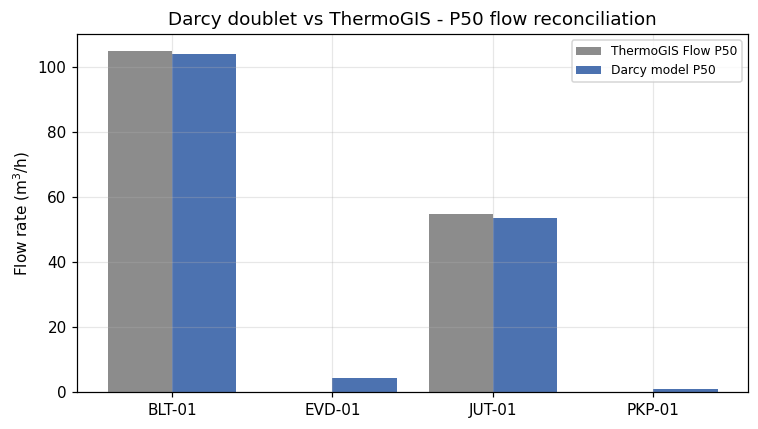

In [3]:
wells = deliver["well"].tolist(); x = np.arange(len(wells))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-0.2, deliver["flow_tg_p50"], 0.4, label="ThermoGIS Flow P50", color="#8c8c8c")
ax.bar(x+0.2, deliver["flow_model_p50"], 0.4, label="Darcy model P50", color="#4c72b0")
ax.set_xticks(x); ax.set_xticklabels(wells); ax.set_ylabel("Flow rate (m$^3$/h)")
ax.set_title("Darcy doublet vs ThermoGIS - P50 flow reconciliation"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES/"deliverability_reconciliation.png"); plt.show()

## 2. Probabilistic MWth - the resource verdict

Two doublets are modelled as the **sum of two independent** single-doublet
realisations (two well pairs sample the play independently), *not* one draw doubled.
The correlated shortcut would force P(2X>=10)=P(X>=5) and understate the result.

In [4]:
mc = simulate_all(tg, n=10_000, anchor="flow")
blt = mc[mc["well"]=="BLT-01"]
summ = pd.concat([summarise(blt, 10.0, n_doublets=k) for k in (1,2,3)], ignore_index=True)
summ

,well,n_doublets,mwth_p90,mwth_p50,mwth_p10,mwth_mean,p_ge_10MWth
0,BLT-01,1,0.86,5.05,14.63,6.60,0.290
1,BLT-01,2,3.76,13.20,23.10,13.22,0.621
2,BLT-01,3,8.06,19.23,31.75,19.75,0.845


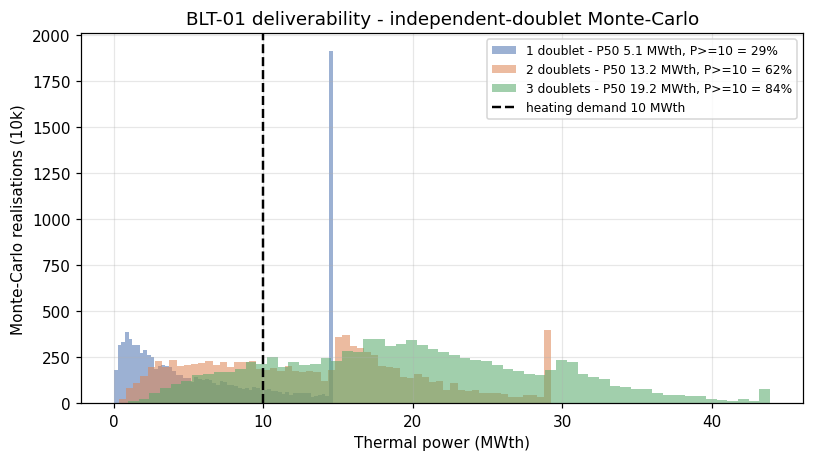

In [5]:
rng = np.random.default_rng(20260607)
base = blt["mwth"].to_numpy()
def scheme(k):
    if k == 1: return base
    s = np.zeros(base.size)
    for _ in range(k): s = s + rng.choice(base, size=base.size, replace=True)
    return s
fig, ax = plt.subplots(figsize=(7.5, 4.3))
for k, c in [(1,"#4c72b0"),(2,"#dd8452"),(3,"#55a868")]:
    s = scheme(k); p = (s >= DEMAND_HEATING_MWTH).mean()
    ax.hist(np.clip(s,0,60), bins=60, alpha=0.55, color=c,
            label=f"{k} doublet{'s' if k>1 else ''} - P50 {np.median(s):.1f} MWth, P>=10 = {p:.0%}")
ax.axvline(DEMAND_HEATING_MWTH, color="k", ls="--", lw=1.6, label="heating demand 10 MWth")
ax.set_xlabel("Thermal power (MWth)"); ax.set_ylabel("Monte-Carlo realisations (10k)")
ax.set_title("BLT-01 deliverability - independent-doublet Monte-Carlo")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIGURES/"mc_mwth_blt.png"); plt.show()

**Verdict.** One doublet (P50 5.05 MWth) clears 10 MWth only 29 % of the time;
**two independent doublets reach P50 13.2 MWth and a 62 % probability of clearing
10 MWth**, with headroom above the demand. The optimistic tail is bounded at a
300 m3/h pump ceiling, and a fully-correlated pair would give a conservative ~10.1
MWth P50 (~50 %) - reality sits between, and the scheme clears 10 MWth at P50 either
way. Two doublets are the honest minimum, and we size the plant to the 10 MWth
*delivered* demand - the surplus de-risks delivery, it does not inflate the economics.

## 3. Petrophysics cross-check - NTG vs ThermoGIS, and why BLT-01 wins

ThermoGIS publishes a play-average net-to-gross (0.95-0.99 for all four wells). Our
log-based NTG applies sample-by-sample cut-offs (V_sh <= 0.40 AND phi >= 0.08): it
**matches at the anchor** (0.93 vs 0.98) and is deliberately **stricter** at the
weaker wells. The resource MWth above is anchored on ThermoGIS *flow*, not our NTG,
so this disagreement sharpens our characterisation without changing Challenge 1.

In [6]:
logs = add_petrophysics(load_all())
summary = pd.DataFrame([rotliegend_summary(logs, rotliegend_pick(w)) for w in WELLS])
summary["our_ntg"] = summary["ntg"]
summary["thermogis_ntg"] = [thermogis_property(tg, w, "Net-to-gross")["p50"] for w in summary["well"]]
disp = summary[["well","gross_tvd_m","net_tvd_m","our_ntg","phi_mean_net","thermogis_ntg"]].round(3)
disp

JUT-01: 2 Slochteren picks; using deepest (top_md=3240.0 m).


,well,gross_tvd_m,net_tvd_m,our_ntg,phi_mean_net,thermogis_ntg
0,BLT-01,122.4,113.8,0.930,0.150,0.98
1,EVD-01,76.8,42.1,0.548,0.109,0.99
2,JUT-01,133.0,42.3,0.318,0.099,0.99
3,PKP-01,64.4,6.6,0.103,0.091,0.95


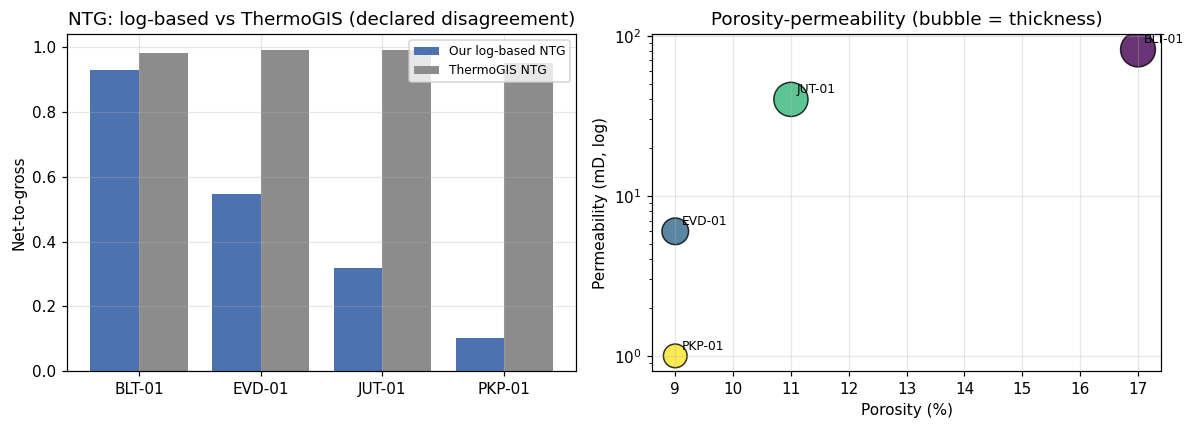

In [7]:
w = summary["well"].tolist(); x = np.arange(len(w))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(x-0.2, summary["our_ntg"], 0.4, label="Our log-based NTG", color="#4c72b0")
axes[0].bar(x+0.2, summary["thermogis_ntg"], 0.4, label="ThermoGIS NTG", color="#8c8c8c")
axes[0].set_xticks(x); axes[0].set_xticklabels(w); axes[0].set_ylabel("Net-to-gross")
axes[0].set_title("NTG: log-based vs ThermoGIS (declared disagreement)"); axes[0].legend(fontsize=8)
# porosity-permeability (ThermoGIS P50), log-y; bubble = thickness
phi = [thermogis_property(tg, ww, "Porosity")["p50"] for ww in w]
k   = [thermogis_property(tg, ww, "Permeability")["p50"] for ww in w]
th  = [thermogis_property(tg, ww, "Thickness")["p50"] for ww in w]
sc = axes[1].scatter(phi, k, s=[t*4 for t in th], c=range(len(w)), cmap="viridis", alpha=0.8, edgecolor="k")
for xi, yi, lab in zip(phi, k, w): axes[1].annotate(lab, (xi, yi), fontsize=8, xytext=(4,4), textcoords="offset points")
axes[1].set_yscale("log"); axes[1].set_xlabel("Porosity (%)"); axes[1].set_ylabel("Permeability (mD, log)")
axes[1].set_title("Porosity-permeability (bubble = thickness)")
fig.tight_layout(); fig.savefig(FIGURES/"ntg_vs_thermogis.png"); plt.show()

BLT-01 sits top-right on porosity-permeability with the thickest interval -
it is the anchor on every axis. PKP-01 is hot (88 C) but at 1 mD it will not flow.

## 4. Cooling adequacy - sizing ATES off the low end

A single ATES warm/cold pair delivers an uncertain 0.5-2.0 MWth of cooling
(triangular, mode 1.0; Fleuchaus et al. 2018). We size the pair count so the demand
is met at the *low* end, not a comfortable midpoint.

In [8]:
rows = [ates_cooling_adequacy(n_pairs=n) for n in range(4, 9)]
adeq = pd.DataFrame(rows)[["n_pairs","supply_p90","supply_p50","supply_mean","p_meets_demand"]]
adeq

,n_pairs,supply_p90,supply_p50,supply_mean,p_meets_demand
0,4,3.87,4.65,4.67,0.293
1,5,4.95,5.82,5.83,0.884
2,6,6.02,6.98,7.00,0.998
3,7,7.12,8.15,8.17,1.000
4,8,8.21,9.31,9.33,1.000


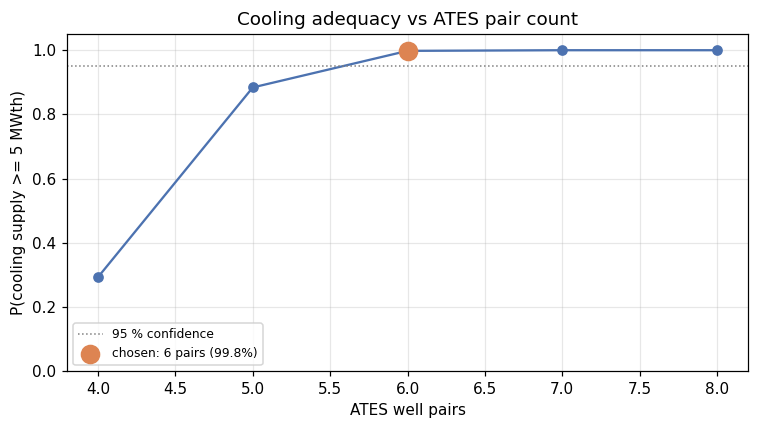

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(adeq["n_pairs"], adeq["p_meets_demand"], "o-", color="#4c72b0")
ax.axhline(0.95, color="grey", ls=":", lw=1, label="95 % confidence")
sel = adeq[adeq["n_pairs"]==6].iloc[0]
ax.scatter([6],[sel["p_meets_demand"]], s=140, color="#dd8452", zorder=5,
           label=f"chosen: 6 pairs ({sel['p_meets_demand']:.1%})")
ax.set_xlabel("ATES well pairs"); ax.set_ylabel("P(cooling supply >= 5 MWth)")
ax.set_ylim(0,1.05); ax.set_title("Cooling adequacy vs ATES pair count")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIGURES/"cooling_adequacy.png"); plt.show()

**4 pairs meet the 5 MWth demand only ~29 % of the time** once throughput
uncertainty is honoured; **6 pairs clear it 99.8 % of the time** (conservative P90
supply 6.0 MWth). That robustness is the honest cost we carry on the cooling side.

## 5. Surface design A vs B, and the recommended scheme

In [10]:
cmp = comparison_table()
cmp[["design","heat_mwth","cooling_mwth","geo_heat_consumed_for_cooling_mwth",
     "ates_pairs","lcoe_heat_eur_gj","lcoe_cool_eur_gj","capex_total_mln"]]

,design,heat_mwth,cooling_mwth,geo_heat_consumed_for_cooling_mwth,ates_pairs,lcoe_heat_eur_gj,lcoe_cool_eur_gj,capex_total_mln
0,A (ATES + heat pump),10.0,5.0,0.00,6,11.76,22.98,21.30
1,B (absorption chiller),10.0,5.0,7.14,0,11.76,23.37,17.75


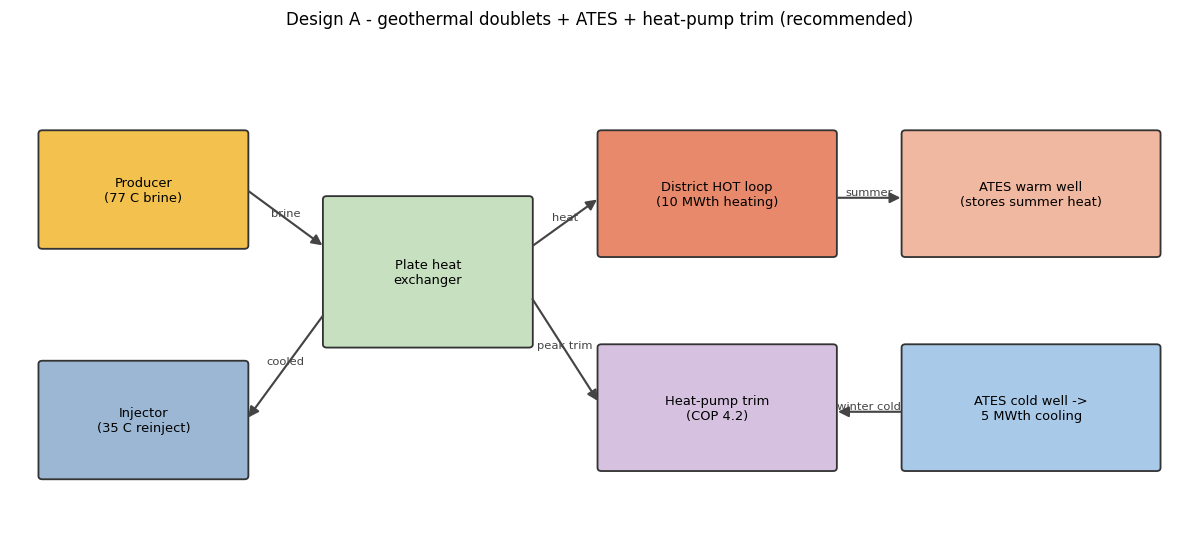

In [11]:
# Design A process-flow schematic
def box(ax, xy, w, h, text, fc):
    ax.add_patch(FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02,rounding_size=0.04",
                                fc=fc, ec="#333", lw=1.2))
    ax.text(xy[0]+w/2, xy[1]+h/2, text, ha="center", va="center", fontsize=8.5, wrap=True)
def arrow(ax, p0, p1, text=""):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=14, lw=1.4, color="#444"))
    if text: ax.text((p0[0]+p1[0])/2, (p0[1]+p1[1])/2+0.03, text, ha="center", fontsize=7.5, color="#444")

fig, ax = plt.subplots(figsize=(11, 5)); ax.set_xlim(0,12); ax.set_ylim(0,6); ax.axis("off")
ax.set_title("Design A - geothermal doublets + ATES + heat-pump trim (recommended)", fontsize=11)
box(ax,(0.3,3.4),2.1,1.4,"Producer\n(77 C brine)","#f2c14e")
box(ax,(0.3,0.6),2.1,1.4,"Injector\n(35 C reinject)","#9bb7d4")
box(ax,(3.2,2.2),2.1,1.8,"Plate heat\nexchanger","#c7e0c0")
box(ax,(6.0,3.3),2.4,1.5,"District HOT loop\n(10 MWth heating)","#e8896b")
box(ax,(6.0,0.7),2.4,1.5,"Heat-pump trim\n(COP 4.2)","#d6c2e0")
box(ax,(9.1,3.3),2.6,1.5,"ATES warm well\n(stores summer heat)","#f0b8a0")
box(ax,(9.1,0.7),2.6,1.5,"ATES cold well ->\n5 MWth cooling","#a9c9e8")
arrow(ax,(2.4,4.1),(3.2,3.4),"brine")
arrow(ax,(3.2,2.6),(2.4,1.3),"cooled")
arrow(ax,(5.3,3.4),(6.0,4.0),"heat")
arrow(ax,(5.3,2.8),(6.0,1.5),"peak trim")
arrow(ax,(8.4,4.0),(9.1,4.0),"summer")
arrow(ax,(9.1,1.4),(8.4,1.4),"winter cold")
fig.tight_layout(); fig.savefig(FIGURES/"design_a_schematic.png", dpi=140); plt.show()

## 6. Recommendation

- **Resource (Challenge 1):** site a **2-doublet (4-well) scheme near BLT-01**.
  P50 13.2 MWth, 62 % chance of clearing the 10 MWth demand; one doublet is not enough.
- **Surface (Challenge 2):** **Design A** - geothermal + 6-pair ATES + heat-pump trim -
  meets 10 MWth heating and 5 MWth cooling (99.8 % cooling adequacy). It beats the
  absorption alternative by keeping the ~7 MWth of saleable heat and by working at
  77 C, with cooling cost a wash (23.0 vs 23.4 EUR/GJ).
- **Economics:** heat 11.8 / cooling 23.0 / **blended 13.4 EUR/GJ**, ~EUR 21.3 M capex -
  ~2x the Dutch heat-only benchmark, fully explained by a cooler, less productive
  reservoir needing four wells for 10 MWth.